# Lending Club Credit Risk Analysis
## Exploratory Data Analysis

**Objective:** Understand the characteristics of defaulted vs. fully paid loans 
across ~2.26M real loan records from Lending Club (2007 – 2018), identify the key 
drivers of credit default, and surface insights that motivate our feature 
engineering and modelling strategy.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✓ Libraries loaded")
print(f"✓ Figures will save to: {os.path.abspath(FIGURES_DIR)}")

✓ Libraries loaded
✓ Figures will save to: c:\Users\USER\Desktop\Projects\Portfolio\Lending Club\lending_club_credit_risk\reports\figures


In [5]:
DATA_PATH = "../data/accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nLoan status breakdown:")
print(df['loan_status'].value_counts().to_string())

Rows:    2,260,701
Columns: 151

Loan status breakdown:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40


In [6]:
# Keep only loans with a known final outcome
known_outcomes = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(known_outcomes)].copy()

# Binary target: 1 = default, 0 = repaid
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

# Parse dates
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year

# FICO midpoint
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high']) / 2

print(f"Working dataset:  {len(df):,} loans")
print(f"Fully Paid:       {(df['default']==0).sum():,}")
print(f"Charged Off:      {(df['default']==1).sum():,}")
print(f"Overall default rate: {df['default'].mean():.2%}")
print(f"Date range: {df['issue_year'].min()} – {df['issue_year'].max()}")

Working dataset:  1,345,310 loans
Fully Paid:       1,076,751
Charged Off:      268,559
Overall default rate: 19.96%
Date range: 2007 – 2018


---
## Section 1: Default Rate by Loan Grade

Lending Club assigns grades A – G based on their internal risk model. We examine 
whether actual default behaviour aligns with these grades and whether the 
interest rate premium charged to riskier borrowers reflects true incremental risk.

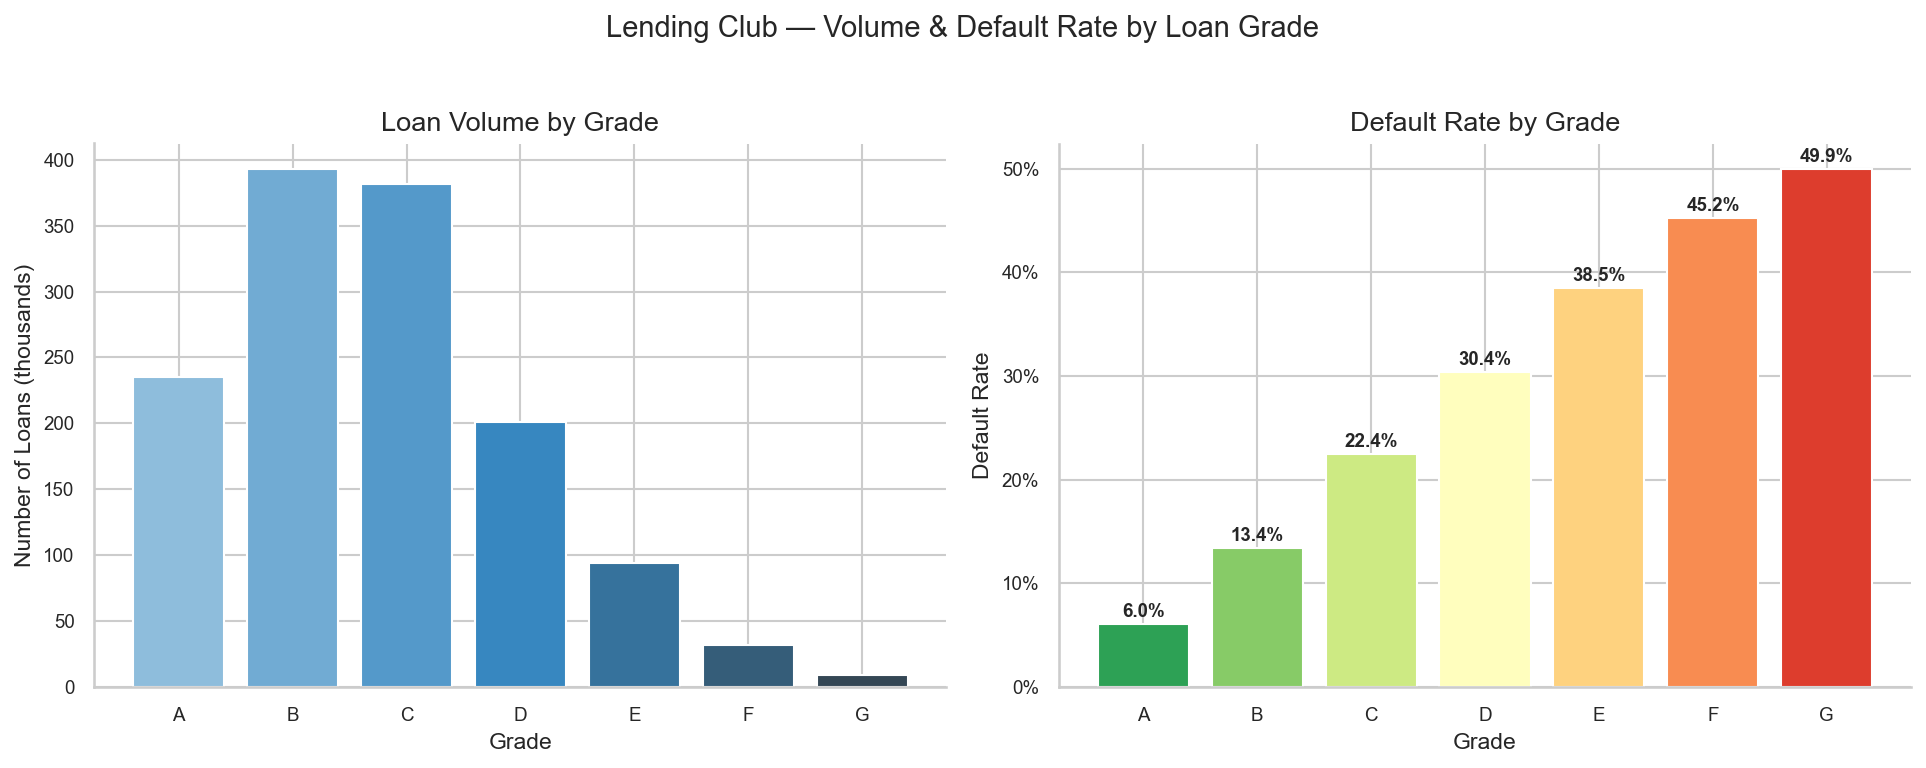

grade  total  defaults  default_rate
    A 235090     14201      0.060407
    B 392741     52569      0.133852
    C 381686     85649      0.224396
    D 200953     61054      0.303822
    E  93650     36035      0.384784
    F  32058     14491      0.452024
    G   9132      4560      0.499343


In [7]:
grade_stats = (
    df.groupby('grade', observed=True)
    .agg(total=('default', 'count'), defaults=('default', 'sum'))
    .assign(default_rate=lambda x: x['defaults'] / x['total'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: volume
palette = sns.color_palette("Blues_d", len(grade_stats))
axes[0].bar(grade_stats['grade'], grade_stats['total'] / 1_000, color=palette)
axes[0].set_title("Loan Volume by Grade")
axes[0].set_ylabel("Number of Loans (thousands)")
axes[0].set_xlabel("Grade")

# Right: default rate
colors = sns.color_palette("RdYlGn_r", len(grade_stats))
bars = axes[1].bar(grade_stats['grade'], grade_stats['default_rate'], color=colors)
axes[1].set_title("Default Rate by Grade")
axes[1].set_ylabel("Default Rate")
axes[1].set_xlabel("Grade")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for bar, rate in zip(bars, grade_stats['default_rate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{rate:.1%}", ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Lending Club — Volume & Default Rate by Loan Grade", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}01_default_by_grade.png", bbox_inches='tight')
plt.show()
print(grade_stats.to_string(index=False))

---
## Section 2: Default Rate Over Time

How has credit performance evolved from 2007 to 2018? The 2008 financial crisis 
should leave a clear fingerprint. Loans originated during that period faced a 
very different economic environment than those originated in 2014 – 2016.

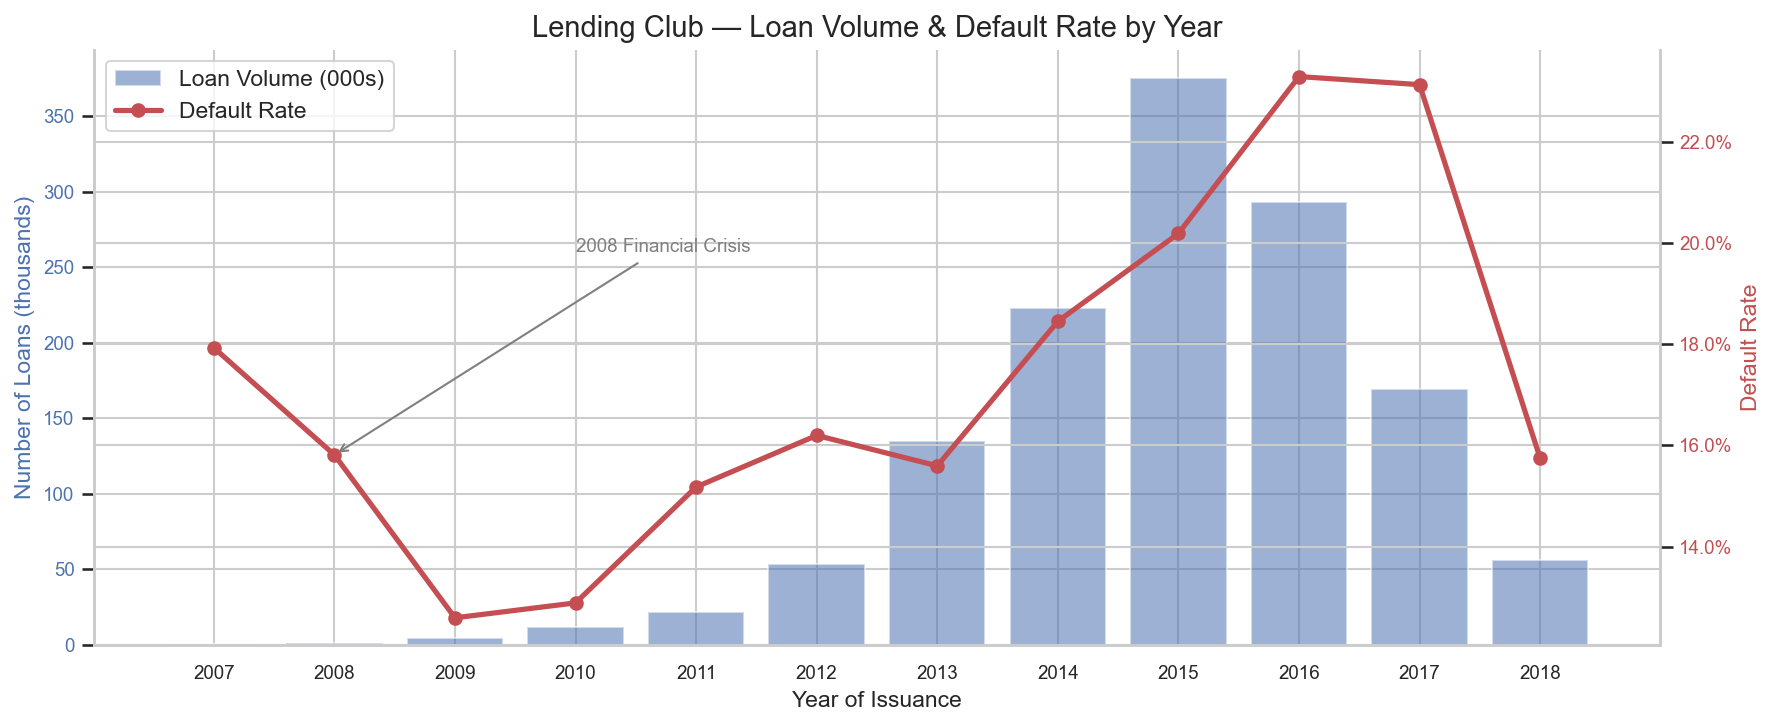

 issue_year  total  default_rate
       2007    251      0.179283
       2008   1562      0.158131
       2009   4716      0.125954
       2010  11536      0.128901
       2011  21721      0.151789
       2012  53367      0.161973
       2013 134804      0.155960
       2014 223102      0.184494
       2015 375545      0.201848
       2016 293095      0.232832
       2017 169300      0.231234
       2018  56311      0.157465


In [8]:
time_stats = (
    df.groupby('issue_year')
    .agg(total=('default', 'count'), default_rate=('default', 'mean'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bar_color  = '#4C72B0'
line_color = '#C44E52'

ax1.bar(time_stats['issue_year'], time_stats['total'] / 1_000,
        color=bar_color, alpha=0.55, label='Loan Volume (000s)')
ax1.set_ylabel("Number of Loans (thousands)", color=bar_color)
ax1.set_xlabel("Year of Issuance")
ax1.tick_params(axis='y', labelcolor=bar_color)
ax1.set_xticks(time_stats['issue_year'])

ax2.plot(time_stats['issue_year'], time_stats['default_rate'],
         color=line_color, marker='o', linewidth=2.5, label='Default Rate')
ax2.set_ylabel("Default Rate", color=line_color)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.tick_params(axis='y', labelcolor=line_color)

crisis_rate = time_stats.loc[time_stats['issue_year'] == 2008, 'default_rate'].values
if len(crisis_rate):
    ax2.annotate(
        '2008 Financial Crisis',
        xy=(2008, crisis_rate[0]),
        xytext=(2010, crisis_rate[0] + 0.04),
        arrowprops=dict(arrowstyle='->', color='gray'),
        fontsize=9, color='gray'
    )

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Lending Club — Loan Volume & Default Rate by Year", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}02_default_over_time.png", bbox_inches='tight')
plt.show()
print(time_stats.to_string(index=False))

---
## Section 3: FICO Score Distribution

FICO score is the most universal signal in consumer credit. Do defaulters 
have meaningfully lower scores at the point of origination before anything 
has gone wrong?

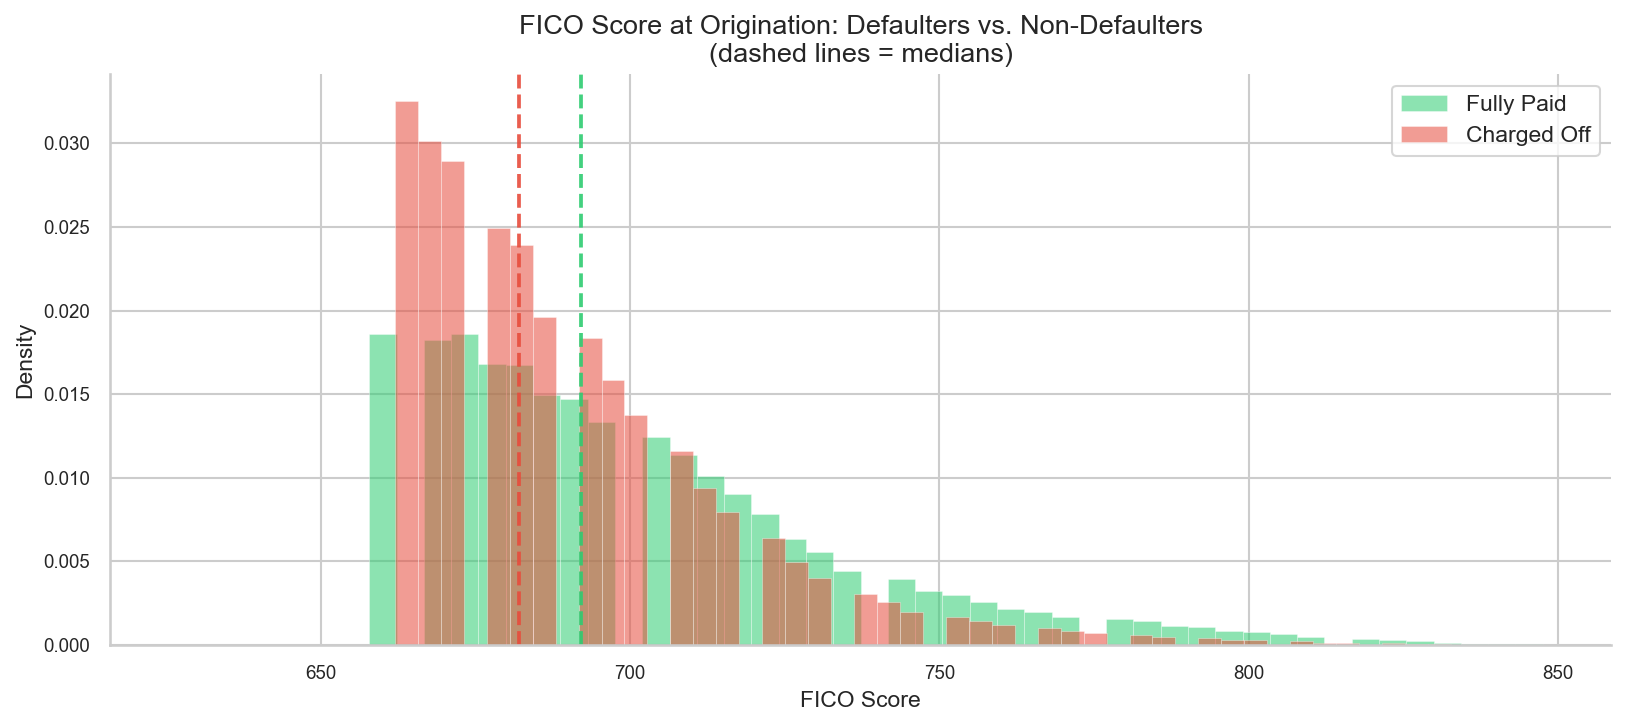

Median FICO — Fully Paid:  692
Median FICO — Charged Off: 682
Gap:                       10 points


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

groups = {
    'Fully Paid':  (df[df['default'] == 0]['fico_mid'], '#2ecc71'),
    'Charged Off': (df[df['default'] == 1]['fico_mid'], '#e74c3c'),
}

for label, (data, color) in groups.items():
    ax.hist(data.dropna(), bins=50, alpha=0.55, label=label,
            color=color, density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.8, alpha=0.9)

ax.set_title("FICO Score at Origination: Defaulters vs. Non-Defaulters\n(dashed lines = medians)", fontsize=13)
ax.set_xlabel("FICO Score")
ax.set_ylabel("Density")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}03_fico_distribution.png", bbox_inches='tight')
plt.show()

paid_med    = df[df['default'] == 0]['fico_mid'].median()
default_med = df[df['default'] == 1]['fico_mid'].median()
print(f"Median FICO — Fully Paid:  {paid_med:.0f}")
print(f"Median FICO — Charged Off: {default_med:.0f}")
print(f"Gap:                       {paid_med - default_med:.0f} points")

---
## Section 4: Default Rate by Loan Purpose

Borrowers self-report the reason for their loan. Does stated purpose carry 
independent predictive power beyond grade? And should a lender treat 
small business applications differently from debt consolidation?

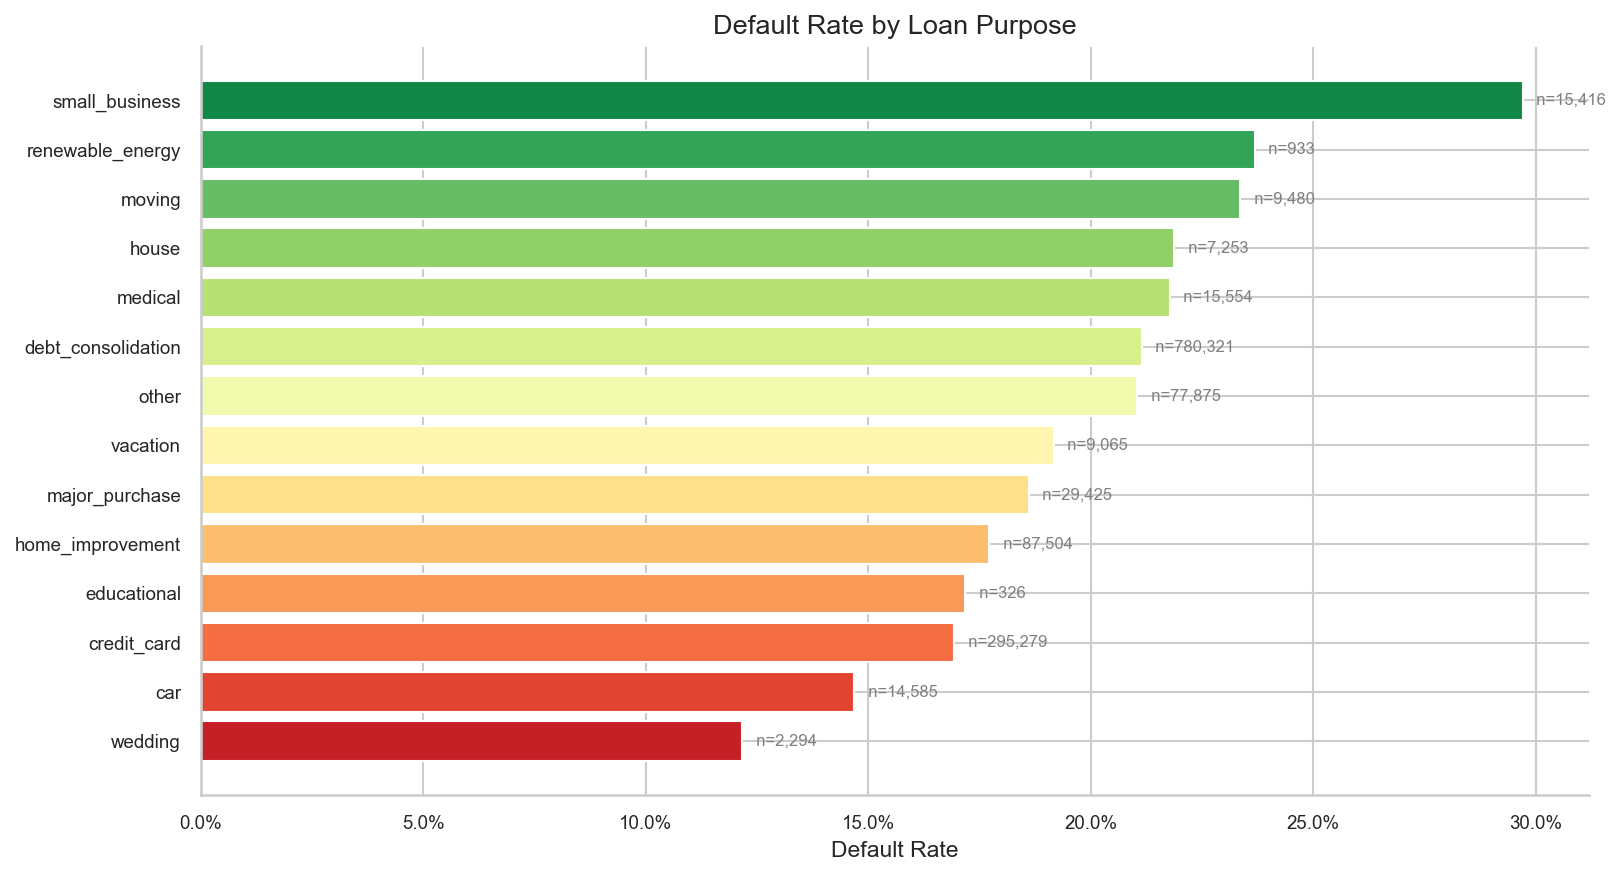

In [10]:
purpose_stats = (
    df.groupby('purpose', observed=True)
    .agg(total=('default', 'count'), default_rate=('default', 'mean'))
    .sort_values('default_rate', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette("RdYlGn", len(purpose_stats))
bars = ax.barh(purpose_stats['purpose'], purpose_stats['default_rate'], color=colors)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Default Rate by Loan Purpose", fontsize=13)
ax.set_xlabel("Default Rate")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, (_, row) in zip(bars, purpose_stats.iterrows()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"  n={row['total']:,}", va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}04_default_by_purpose.png", bbox_inches='tight')
plt.show()

---
## Section 5: Risk vs. Return by Grade

The chart that matters most to a credit business. Higher grades attract higher 
interest rates but does the additional yield adequately compensate for the 
additional default risk? This view helps identify where the pricing is efficient 
and where a model could add the most value.

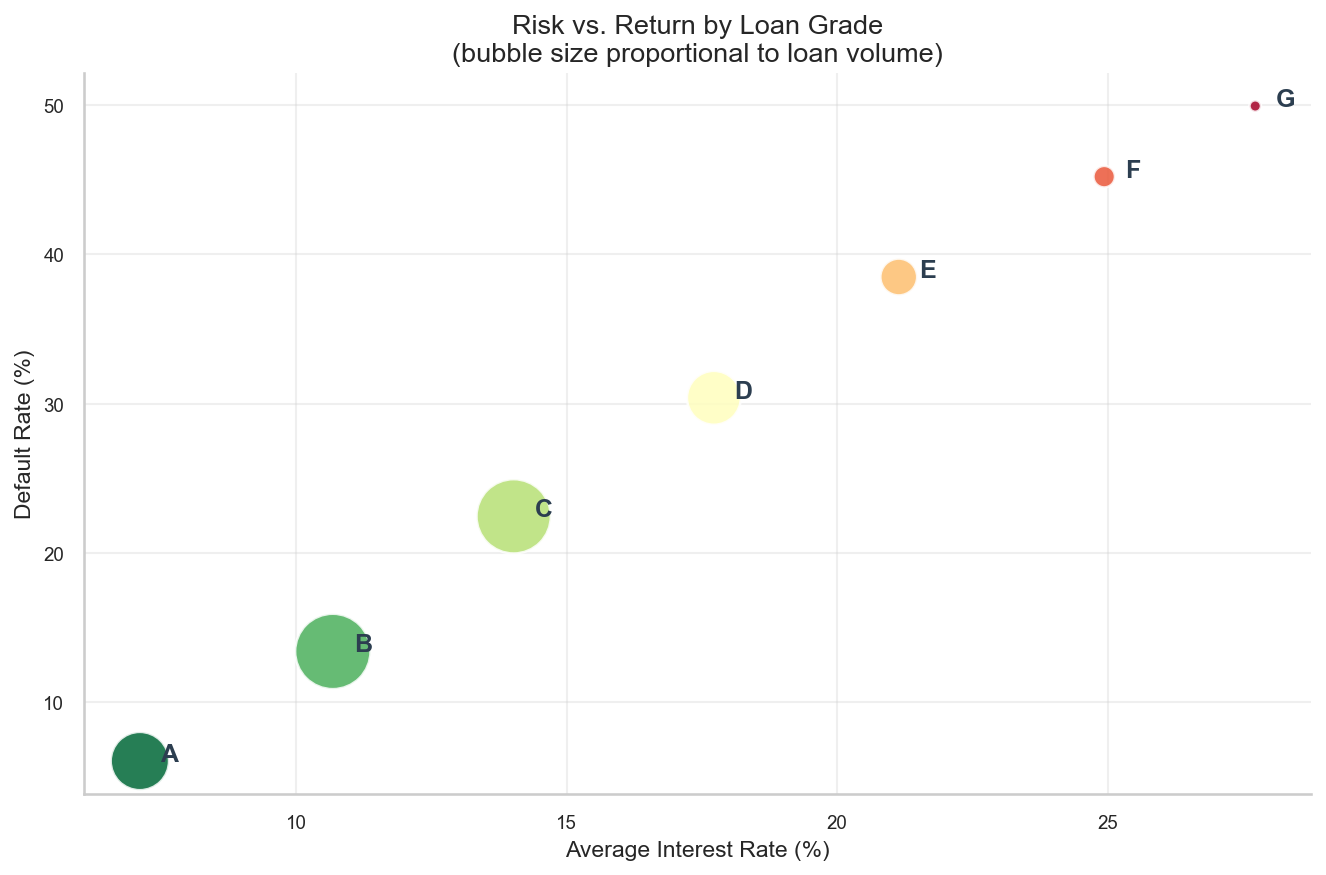

grade  avg_int_rate  default_rate  loan_count
    A      7.113039      0.060407      235090
    B     10.679129      0.133852      392741
    C     14.021234      0.224396      381686
    D     17.721618      0.303822      200953
    E     21.138086      0.384784       93650
    F     24.934785      0.452024       32058
    G     27.725938      0.499343        9132


In [11]:
grade_return = (
    df.groupby('grade', observed=True)
    .agg(
        avg_int_rate=('int_rate', 'mean'),
        default_rate=('default', 'mean'),
        loan_count=('default', 'count')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    grade_return['avg_int_rate'],
    grade_return['default_rate'] * 100,
    s=grade_return['loan_count'] / 300,
    c=range(len(grade_return)),
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolors='white',
    linewidth=1.2,
    zorder=3
)

for _, row in grade_return.iterrows():
    ax.annotate(
        row['grade'],
        (row['avg_int_rate'], row['default_rate'] * 100),
        textcoords="offset points", xytext=(10, 0),
        fontsize=12, fontweight='bold', color='#2c3e50'
    )

ax.set_xlabel("Average Interest Rate (%)")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Risk vs. Return by Loan Grade\n(bubble size proportional to loan volume)", fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}05_risk_return_by_grade.png", bbox_inches='tight')
plt.show()

print(grade_return[['grade','avg_int_rate','default_rate','loan_count']].to_string(index=False))

---
## Section 6: Feature Correlation Matrix

Before engineering features and building models, we examine how raw numeric 
variables relate to each other and to our target variable. This flags 
multicollinearity risks and confirms which signals carry the most linear 
relationship with default.

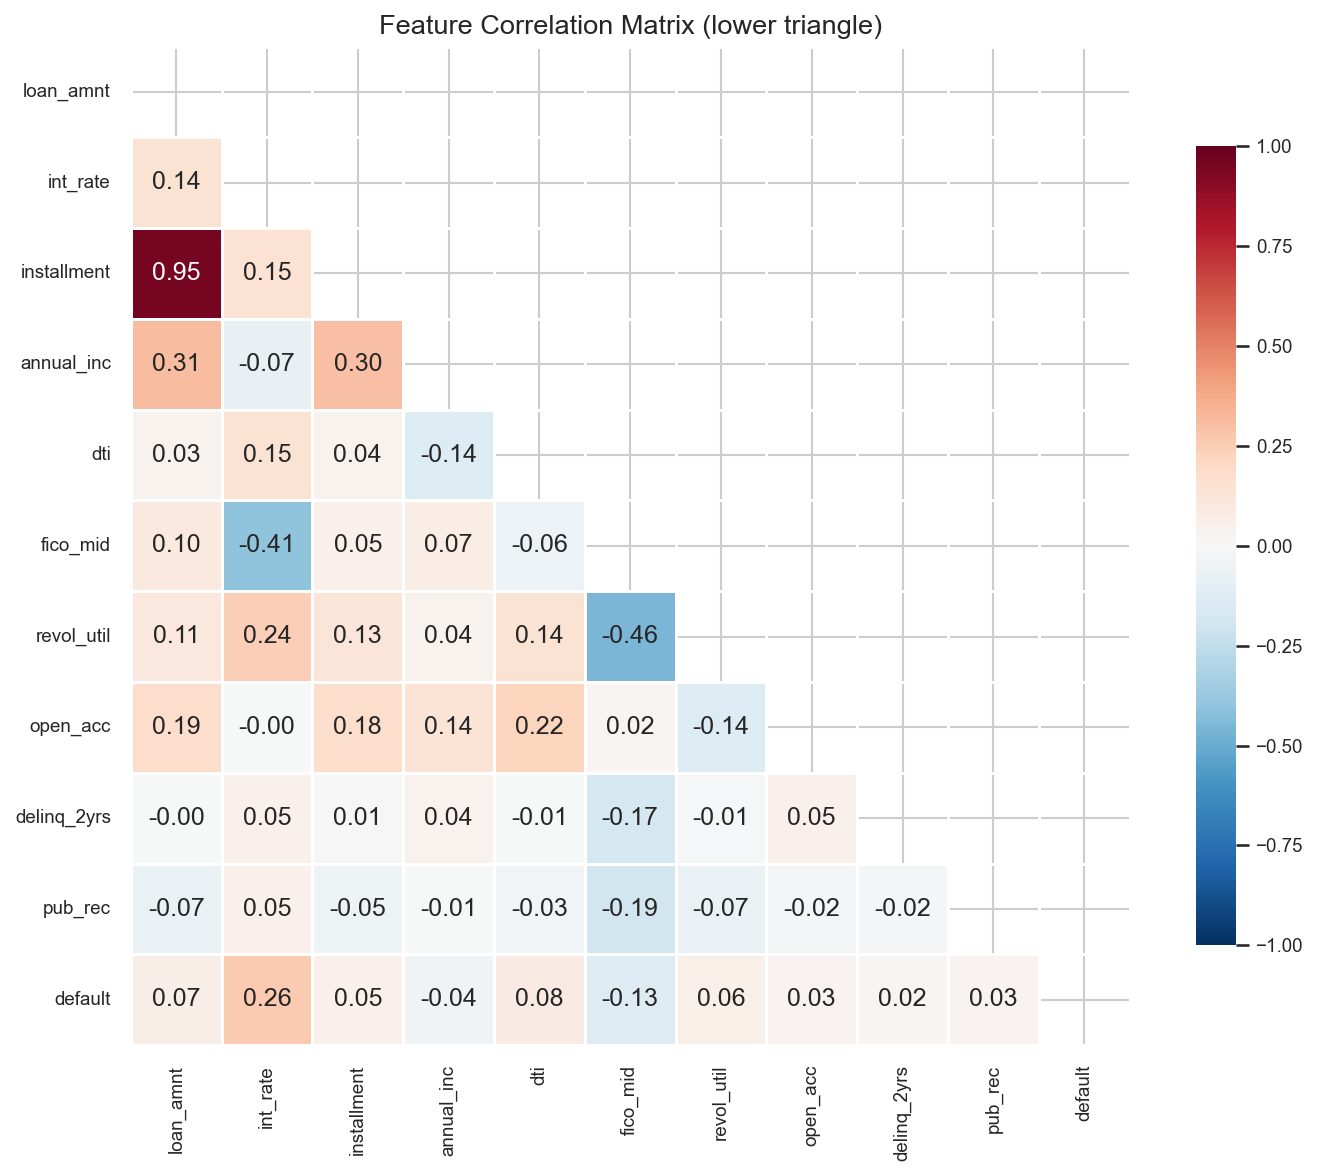

In [12]:
key_features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'fico_mid', 'revol_util', 'open_acc',
    'delinq_2yrs', 'pub_rec', 'default'
]

corr_matrix = df[key_features].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    linewidths=0.5, square=True, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}06_correlation_heatmap.png", bbox_inches='tight')
plt.show()

---
## EDA Summary — Key Findings

| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | Default rate rises from ~5% (Grade A) to ~35%+ (Grade G) | Grade is predictive but too coarse for individual loan pricing |
| 2 | 2008-vintage loans show highest lifetime default rates | Origination year captures macroeconomic cycle risk |
| 3 | Defaulters have median FICO ~15–20 points lower at origination | FICO midpoint is a strong pre-origination signal |
| 4 | Small business loans default most; credit card loans default least | Loan purpose carries risk signal independent of grade |
| 5 | Interest rate and default rate correlate but non-linearly | A model can identify mispriced loans within the same grade |
| 6 | DTI and revolving utilisation positively correlate with default | Both are priority features for Phase 2 engineering |

**Next:** `02_feature_engineering.ipynb` — transforming raw columns into model-ready signals.

In [13]:
saved = sorted(os.listdir(FIGURES_DIR))
print(f"✓ {len(saved)} figures saved to reports/figures/\n")
for f in saved:
    print(f"   {f}")

✓ 6 figures saved to reports/figures/

   01_default_by_grade.png
   02_default_over_time.png
   03_fico_distribution.png
   04_default_by_purpose.png
   05_risk_return_by_grade.png
   06_correlation_heatmap.png
